# Vol.05: テクニカル指標の作成と評価
**暗号資産データ分析入門シリーズ**

---

**テーマ**: テクニカル指標を「自分で実装」し、その統計的な性質を定量的に評価する

### なぜテクニカル指標から始めるのか

Vol.04 では、銘柄間のリードラグ分析を行い、主要暗号資産間に日足レベルの先行・遅行関係がほとんど存在しないことを確認しました。ここからは、**1つの銘柄の過去の情報**から将来のリターンを予測できる指標を探索する方向に進みます。

その最初の題材として**テクニカル指標**を取り上げます。テクニカル指標を選ぶ理由は以下のとおりです。

- **価格データ（OHLCV）だけで計算できる**: 外部データソースが不要で、データ加工のハードルが低い
- **計算ロジックが明快**: 移動平均やRSIは数行のコードで実装でき、「指標を作る → 評価する」のワークフローを学ぶ最初の例として適している
- **トレーダーの共通言語**: RSIやボリンジャーバンドは世界中のトレーダーが参照しており、市場参加者の行動を理解する手がかりになる

### テクニカル指標の限界

一方で、テクニカル指標に対して過度な期待を持つべきではありません。

- **万能ではない**: どの指標にも「効く相場環境」と「効かない相場環境」がある。RSIの逆張りは横ばい相場では機能しやすいが、強いトレンド相場では裏目に出る
- **全期間を通じて安定した収益を出す単一の指標はほぼ存在しない**: これは Vol.08（頑健性検証）で確認する
- **同じ指標を多くのトレーダーが見ている**: 広く知られた指標のエッジは市場に織り込まれやすい

このnotebookの目的は、「テクニカル指標で儲かる戦略を作る」ことではなく、**指標を作成し、その統計的性質を定量的に評価するスキルを身につける**ことです。このスキルはテクニカル指標に限らず、あらゆるシグナルの評価に応用できます。

### このnotebookで学ぶこと

| テーマ | 内容 |
|--------|------|
| **移動平均（SMA, EMA）** | トレンドフォロー指標の仕組みと実装 |
| **モメンタム・オシレーター指標（RSI, ROC）** | 買われすぎ・売られすぎの定量化 |
| **ボラティリティ指標（ATR, BB幅）** | 値動きの大きさの測定 |
| **指標と将来リターンの関係** | 各指標が予測力を持つかの検証 |
| **指標の自己相関** | 指標値の「粘着性」の分析 |
| **指標間の相関（冗長性チェック）** | 複数指標を組み合わせる際の注意点 |

### 対象データ
- **銘柄**: BTC/USDT（Binance）
- **足種**: 1時間足
- **期間**: 2024年1月1日 〜 2025年1月1日（約8,760本）

## 1. 環境準備

In [1]:
!pip install requests pandas numpy matplotlib japanize-matplotlib scipy -q

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy import stats
import time

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
print("ライブラリの読み込み完了")

ライブラリの読み込み完了


## 2. データ取得

BTC/USDTの**1時間足**データを取得します。

- 期間: 2024-01-01 〜 2025-01-01
- 約8,760本の足データ（十分なサンプル数）
- テクニカル指標の計算には、ある程度の長さの時系列が必要です

In [3]:
BINANCE_API_URL = "https://api.binance.com/api/v3/klines"

def fetch_ohlcv(symbol, interval, start_date, end_date, limit=1000):
    """
    Binance REST API から OHLCV データを取得する。

    Parameters
    ----------
    symbol : str     — 銘柄（例: 'BTCUSDT'）
    interval : str   — 時間足（例: '1h', '5m', '1d'）
    start_date : str — 開始日（例: '2024-01-01'）
    end_date : str   — 終了日（例: '2025-01-01'）※この日は含まない
    limit : int      — 1回のリクエストあたりの取得本数（最大1000）

    Returns
    -------
    pd.DataFrame — columns: [open, high, low, close, volume], index: timestamp (UTC)
    """
    start_ts = int(pd.Timestamp(start_date, tz="UTC").timestamp() * 1000)
    end_ts = int(pd.Timestamp(end_date, tz="UTC").timestamp() * 1000)

    all_data = []
    current_ts = start_ts

    while current_ts < end_ts:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ts,
            "endTime": end_ts - 1,  # endTime は inclusive なので -1
            "limit": limit,
        }
        resp = requests.get(BINANCE_API_URL, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_data.extend(data)
        current_ts = data[-1][0] + 1  # 最後のレコードの次から再開
        time.sleep(0.2)  # レートリミット遵守（200ms間隔）

    if not all_data:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume"])

    df = pd.DataFrame(all_data, columns=[
        "timestamp", "open", "high", "low", "close", "volume",
        "_close_time", "_quote_vol", "_trades", "_taker_buy_vol",
        "_taker_buy_quote", "_ignore",
    ])

    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)

    df = df[["timestamp", "open", "high", "low", "close", "volume"]]
    df = df.set_index("timestamp").sort_index()
    df = df[~df.index.duplicated(keep="first")]

    return df

# BTC/USDT 1時間足データを取得
print("BTC/USDT 1時間足データを取得中...")
df_1h = fetch_ohlcv("BTCUSDT", "1h", "2024-01-01", "2025-01-01")

# 期間内のデータのみ保持
df_1h = df_1h[df_1h.index < "2025-01-01"]

print(f"  最終データ件数: {len(df_1h)}")
print(f"  期間: {df_1h.index[0]} → {df_1h.index[-1]}")
df_1h.describe()

BTC/USDT 1時間足データを取得中...


  最終データ件数: 8784
  期間: 2024-01-01 00:00:00+00:00 → 2024-12-31 23:00:00+00:00


,open,high,low,close,volume
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,65893.115044,66140.217911,65634.169937,65898.952048,1472.121149
std,14678.547431,14737.092246,14617.314323,14679.355540,1484.764525
min,38767.750000,38900.000000,38555.000000,38767.740000,92.165510
25%,59012.757500,59246.282500,58741.000000,59013.122500,622.963705
50%,64202.315000,64412.385000,63968.120000,64203.095000,1014.774035
75%,69042.632500,69265.050000,68800.387500,69044.215000,1760.258963
max,108258.380000,108353.000000,107130.000000,108258.390000,23219.736890


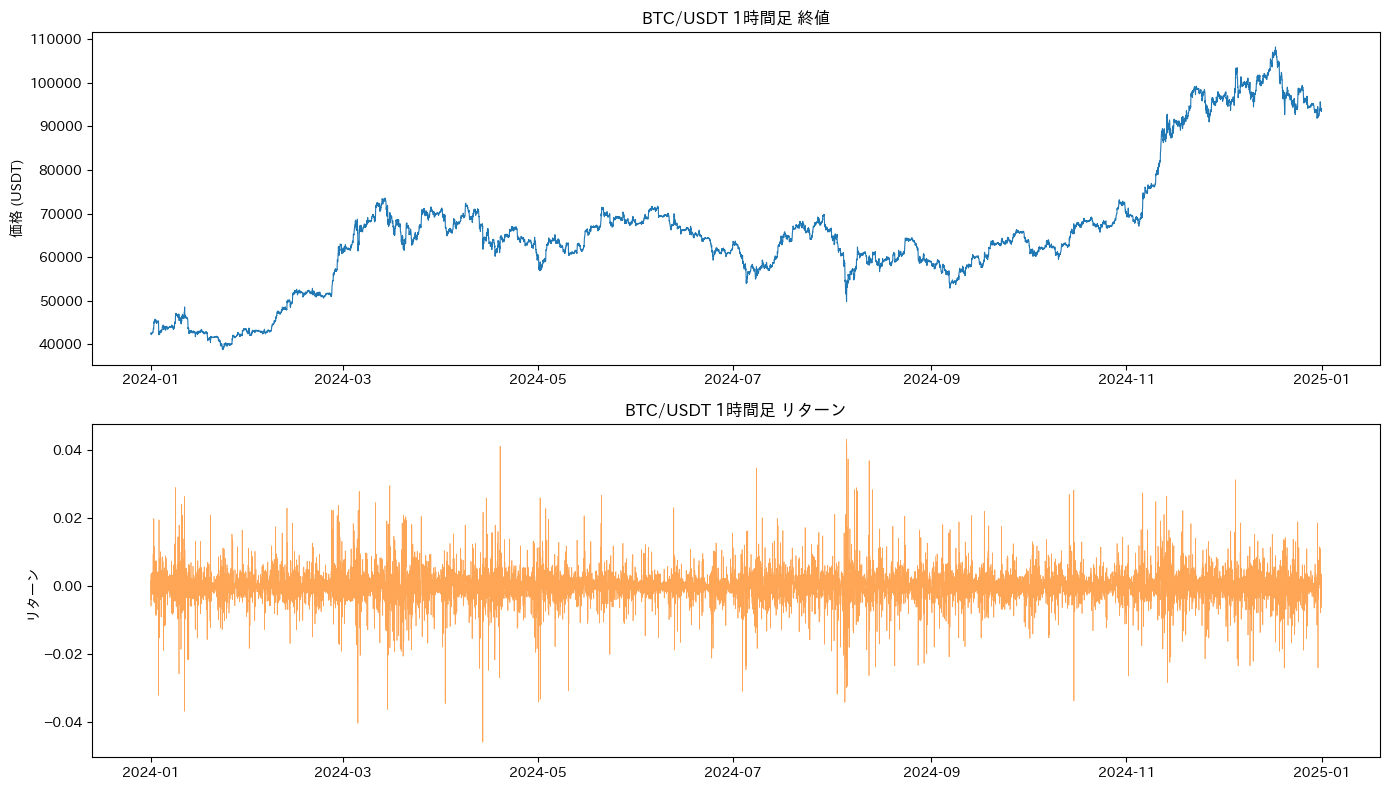

リターンの基本統計量:
count    8783.000000
mean        0.000106
std         0.005617
min        -0.045873
25%        -0.002277
50%         0.000090
75%         0.002566
max         0.043109
Name: ret, dtype: float64


In [4]:
# リターンを計算しておく
df_1h["ret"] = df_1h["close"].pct_change()

# 価格の推移を確認
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_1h.index, df_1h["close"], linewidth=0.8, color="C0")
axes[0].set_title("BTC/USDT 1時間足 終値")
axes[0].set_ylabel("価格 (USDT)")

axes[1].plot(df_1h.index, df_1h["ret"], linewidth=0.5, alpha=0.7, color="C1")
axes[1].set_title("BTC/USDT 1時間足 リターン")
axes[1].set_ylabel("リターン")

plt.tight_layout()
plt.show()

print(f"リターンの基本統計量:")
print(df_1h["ret"].describe())

## 3. 移動平均（SMA, EMA）の実装

移動平均は最も基本的なテクニカル指標で、**価格のトレンド方向**を把握するために使います。

### SMA（単純移動平均）

過去 $n$ 期間の終値の算術平均です。

$$
\text{SMA}(t, n) = \frac{1}{n} \sum_{i=0}^{n-1} P(t-i)
$$

- すべての過去データに**等しい重み**を与えます
- 直近の変化への反応が遅い（ラグが大きい）

### EMA（指数移動平均）

直近のデータに**より大きな重み**を与える移動平均です。

$$
\text{EMA}(t) = \alpha \cdot P(t) + (1 - \alpha) \cdot \text{EMA}(t-1)
$$

ここで $\alpha = \frac{2}{n+1}$ は平滑化係数です。

- 直近の価格変化に素早く反応する
- SMAよりラグが小さい

In [5]:
def calc_sma(series, window):
    """
    単純移動平均（SMA）をスクラッチで計算する。

    Parameters
    ----------
    series : pd.Series
        入力データ（通常は終値）
    window : int
        ウィンドウ幅（期間数）

    Returns
    -------
    pd.Series
        SMAの値。最初の (window-1) 期間は NaN になる。
    """
    # rolling().mean() と同等の処理を手動で実装
    sma = pd.Series(np.nan, index=series.index)
    for i in range(window - 1, len(series)):
        sma.iloc[i] = series.iloc[i - window + 1 : i + 1].mean()
    return sma


def calc_ema(series, window):
    """
    指数移動平均（EMA）をスクラッチで計算する。

    Parameters
    ----------
    series : pd.Series
        入力データ
    window : int
        ウィンドウ幅（EMAの期間数）

    Returns
    -------
    pd.Series
        EMAの値
    """
    alpha = 2.0 / (window + 1)
    ema = pd.Series(np.nan, index=series.index)

    # 最初のEMA値はSMAで初期化する（一般的な手法）
    first_valid = series.iloc[:window].mean()
    ema.iloc[window - 1] = first_valid

    # 再帰的にEMAを計算
    for i in range(window, len(series)):
        ema.iloc[i] = alpha * series.iloc[i] + (1 - alpha) * ema.iloc[i - 1]

    return ema


# pandasの組み込み関数と結果を比較して正しさを検証
close = df_1h["close"]

sma_20_manual = calc_sma(close, 20)
sma_20_pandas = close.rolling(20).mean()
ema_20_manual = calc_ema(close, 20)
ema_20_pandas = close.ewm(span=20, adjust=False).mean()

# 最初のwindow分を除いて比較
sma_diff = (sma_20_manual.dropna() - sma_20_pandas.dropna()).abs().max()
print(f"SMA(20) の最大誤差: {sma_diff:.10f}")

# EMAは初期値の設定で微小な差が出る場合がある
ema_diff = (ema_20_manual.dropna() - ema_20_pandas.iloc[19:]).abs()
print(f"EMA(20) の最大誤差: {ema_diff.max():.10f}")
print(f"EMA(20) の平均誤差: {ema_diff.mean():.10f}")
print()
print("→ どちらも誤差が十分に小さく、実装が正しいことを確認")

SMA(20) の最大誤差: 0.0000000000
EMA(20) の最大誤差: 88.4882401565
EMA(20) の平均誤差: 0.1060041668

→ どちらも誤差が十分に小さく、実装が正しいことを確認


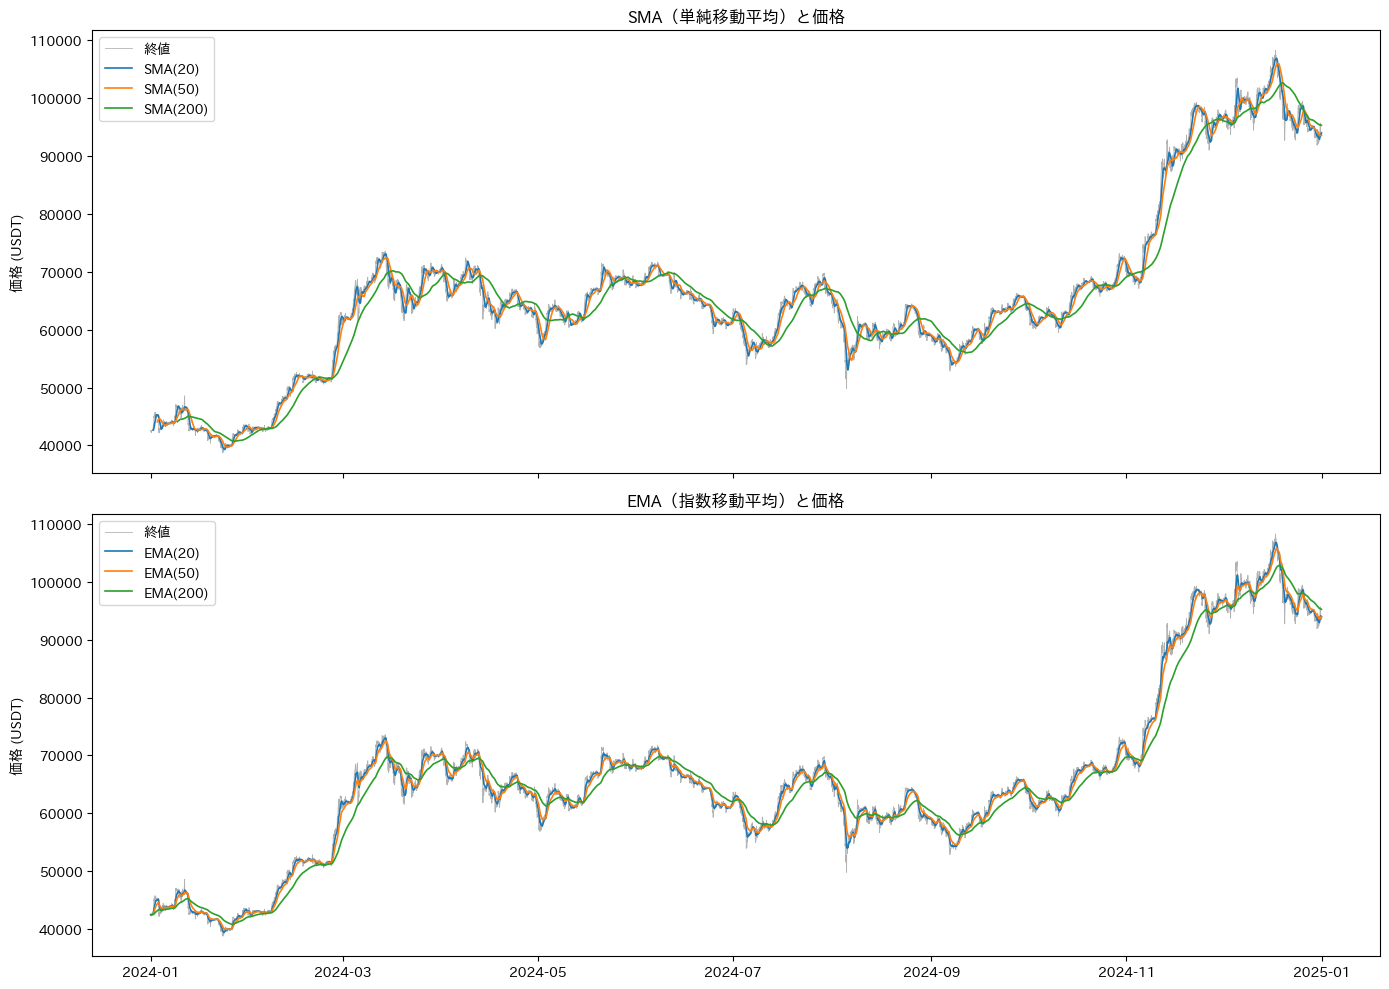

In [6]:
# 以降は高速なpandas版を使用する
# 複数のウィンドウ幅でSMA・EMAを計算
for w in [20, 50, 200]:
    df_1h[f"sma_{w}"] = df_1h["close"].rolling(w).mean()
    df_1h[f"ema_{w}"] = df_1h["close"].ewm(span=w, adjust=False).mean()

# 移動平均と価格のプロット
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# SMAのプロット
ax = axes[0]
ax.plot(df_1h.index, df_1h["close"], linewidth=0.6, alpha=0.6, color="gray", label="終値")
for w, color in zip([20, 50, 200], ["C0", "C1", "C2"]):
    ax.plot(df_1h.index, df_1h[f"sma_{w}"], linewidth=1.2, color=color, label=f"SMA({w})")
ax.set_title("SMA（単純移動平均）と価格")
ax.set_ylabel("価格 (USDT)")
ax.legend(loc="upper left")

# EMAのプロット
ax = axes[1]
ax.plot(df_1h.index, df_1h["close"], linewidth=0.6, alpha=0.6, color="gray", label="終値")
for w, color in zip([20, 50, 200], ["C0", "C1", "C2"]):
    ax.plot(df_1h.index, df_1h[f"ema_{w}"], linewidth=1.2, color=color, label=f"EMA({w})")
ax.set_title("EMA（指数移動平均）と価格")
ax.set_ylabel("価格 (USDT)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

### 移動平均の読み方

| パターン | 意味 |
|----------|------|
| 価格 > SMA | 短期的に上昇トレンド |
| SMA(短期) > SMA(長期) | トレンド転換の可能性（ゴールデンクロス） |
| SMA(短期) < SMA(長期) | 下降トレンド転換の可能性（デッドクロス） |
| EMAはSMAより価格に近い | EMAの方が直近の動きに敏感 |

**注意**: 移動平均はあくまで「遅行指標」です。トレンドが発生した**あと**に反応するため、ラグが必ず存在します。ウィンドウ幅が大きいほどラグも大きくなります。

## 4. モメンタム・オシレーター指標（RSI, ROC）の実装

モメンタム・オシレーター指標は、価格変化の**速度や勢い**を測定します。
トレンドの強弱や「買われすぎ・売られすぎ」の判断に使われます。

### RSI（Relative Strength Index）

RSIは価格の上昇幅と下落幅の比率から、0〜100の値を算出します。

$$
\text{RSI} = 100 - \frac{100}{1 + RS}
$$

$$
RS = \frac{\text{平均上昇幅}}{\text{平均下落幅}}
$$

- RSI > 70 → **買われすぎ**（反落の可能性）
- RSI < 30 → **売られすぎ**（反発の可能性）
- RSI ≈ 50 → 方向感なし

### ROC（Rate of Change）

ROCは、$n$期間前の価格との変化率を%で表します。

$$
\text{ROC}(t, n) = \frac{P(t) - P(t-n)}{P(t-n)} \times 100
$$

- ROC > 0 → 価格は $n$ 期間前より上昇
- ROC < 0 → 価格は $n$ 期間前より下落
- 値の大きさ → 変化の勢いの強さ

In [7]:
def calc_rsi(series, window=14):
    """
    RSI（Relative Strength Index）をスクラッチで計算する。

    Wilderの平滑化（指数移動平均の一種）を使用する。

    Parameters
    ----------
    series : pd.Series
        入力データ（通常は終値）
    window : int
        ウィンドウ幅（デフォルト: 14）

    Returns
    -------
    pd.Series
        RSIの値（0〜100）
    """
    # 価格変化を計算
    delta = series.diff()

    # 上昇分と下落分を分離
    gain = delta.clip(lower=0)  # 正の変化（上昇）のみ
    loss = (-delta).clip(lower=0)  # 負の変化（下落）の絶対値

    # Wilderの平滑化（α = 1/window の指数移動平均）
    # 最初のwindow期間はSMAで初期化
    avg_gain = pd.Series(np.nan, index=series.index)
    avg_loss = pd.Series(np.nan, index=series.index)

    avg_gain.iloc[window] = gain.iloc[1:window + 1].mean()
    avg_loss.iloc[window] = loss.iloc[1:window + 1].mean()

    # 以降は再帰的に計算
    for i in range(window + 1, len(series)):
        avg_gain.iloc[i] = (avg_gain.iloc[i - 1] * (window - 1) + gain.iloc[i]) / window
        avg_loss.iloc[i] = (avg_loss.iloc[i - 1] * (window - 1) + loss.iloc[i]) / window

    # RS = 平均上昇幅 / 平均下落幅
    rs = avg_gain / avg_loss

    # RSI = 100 - 100 / (1 + RS)
    rsi = 100 - 100 / (1 + rs)

    return rsi


def calc_roc(series, window=12):
    """
    ROC（Rate of Change）を計算する。

    Parameters
    ----------
    series : pd.Series
        入力データ（通常は終値）
    window : int
        ウィンドウ幅（デフォルト: 12）

    Returns
    -------
    pd.Series
        ROCの値（%表示）
    """
    roc = (series - series.shift(window)) / series.shift(window) * 100
    return roc


# RSIとROCを計算
df_1h["rsi_14"] = calc_rsi(df_1h["close"], window=14)
df_1h["roc_12"] = calc_roc(df_1h["close"], window=12)

print("RSI(14) の基本統計量:")
print(df_1h["rsi_14"].describe())
print()
print("ROC(12) の基本統計量:")
print(df_1h["roc_12"].describe())

RSI(14) の基本統計量:
count    8770.000000
mean       51.473897
std        11.966096
min        14.402371
25%        43.777537
50%        51.400311
75%        58.937695
max        90.153680
Name: rsi_14, dtype: float64

ROC(12) の基本統計量:
count    8772.000000
mean        0.127206
std         1.897863
min       -12.483567
25%        -0.795183
50%         0.095337
75%         1.004367
max        12.517067
Name: roc_12, dtype: float64


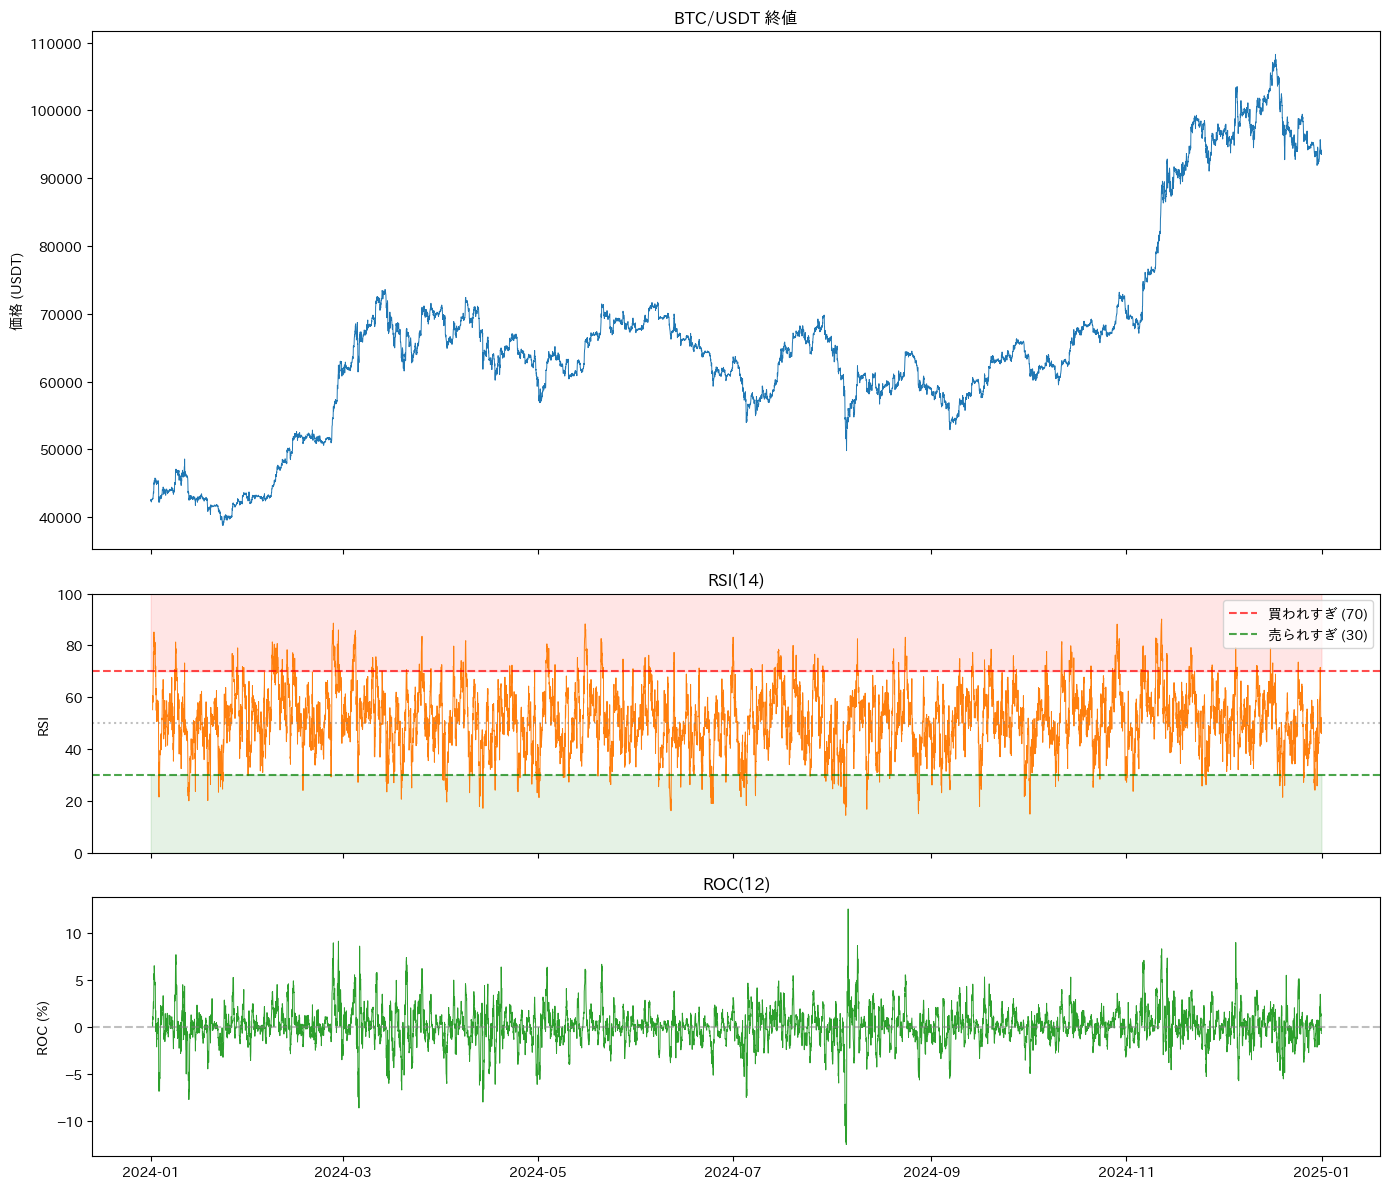

In [8]:
# RSIとROCのプロット
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1, 1]})

# 価格
ax = axes[0]
ax.plot(df_1h.index, df_1h["close"], linewidth=0.7, color="C0")
ax.set_title("BTC/USDT 終値")
ax.set_ylabel("価格 (USDT)")

# RSI
ax = axes[1]
ax.plot(df_1h.index, df_1h["rsi_14"], linewidth=0.7, color="C1")
ax.axhline(y=70, color="red", linestyle="--", alpha=0.7, label="買われすぎ (70)")
ax.axhline(y=30, color="green", linestyle="--", alpha=0.7, label="売られすぎ (30)")
ax.axhline(y=50, color="gray", linestyle=":", alpha=0.5)
ax.fill_between(df_1h.index, 70, 100, alpha=0.1, color="red")
ax.fill_between(df_1h.index, 0, 30, alpha=0.1, color="green")
ax.set_title("RSI(14)")
ax.set_ylabel("RSI")
ax.set_ylim(0, 100)
ax.legend(loc="upper right")

# ROC
ax = axes[2]
ax.plot(df_1h.index, df_1h["roc_12"], linewidth=0.7, color="C2")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_title("ROC(12)")
ax.set_ylabel("ROC (%)")

plt.tight_layout()
plt.show()

### モメンタム・オシレーター指標の読み方

**RSIの解釈:**
- RSIが70を超えると「買われすぎ」とされ、そこから反転下落する可能性がある
- RSIが30を下回ると「売られすぎ」とされ、そこから反転上昇する可能性がある
- ただし、強いトレンド中はRSIが長期間70超（30未満）に留まることもある

**ROCの解釈:**
- ROCはシンプルな変化率なので直感的に理解しやすい
- ゼロラインの上下で上昇・下降トレンドを判断できる
- 極端に大きな値は「行き過ぎ」を示唆する可能性がある

## 5. ボラティリティ指標（ATR, ボリンジャーバンド幅）の実装

ボラティリティ指標は、価格の**変動の大きさ**を測定します。
リスク管理やポジションサイジングに不可欠な指標です。

### ATR（Average True Range）

ATRは、**真の値幅（True Range）** の移動平均です。

$$
\text{TR}(t) = \max\left( H(t) - L(t),\; |H(t) - C(t-1)|,\; |L(t) - C(t-1)| \right)
$$

$$
\text{ATR}(t, n) = \frac{1}{n} \sum_{i=0}^{n-1} \text{TR}(t-i)
$$

- True Range はギャップ（前の足の終値と現在の足の始値の差）も考慮する
- ATR が大きい → ボラティリティが高い
- ATR が小さい → ボラティリティが低い（レンジ相場の可能性）

### ボリンジャーバンド幅

ボリンジャーバンドは、移動平均の上下に標準偏差の倍数を加えたバンドです。

$$
\text{上バンド} = \text{SMA}(n) + k \cdot \sigma(n)
$$
$$
\text{下バンド} = \text{SMA}(n) - k \cdot \sigma(n)
$$
$$
\text{BB幅} = \frac{\text{上バンド} - \text{下バンド}}{\text{SMA}(n)}
$$

- $k$ は通常2（2σ = 約95%の範囲）
- BB幅が広い → ボラティリティが高い
- BB幅が狭い → ボラティリティが低い（スクイーズ → ブレイクアウトの前兆？）

In [9]:
def calc_atr(high, low, close, window=14):
    """
    ATR（Average True Range）をスクラッチで計算する。

    Parameters
    ----------
    high : pd.Series
        高値
    low : pd.Series
        安値
    close : pd.Series
        終値
    window : int
        ウィンドウ幅（デフォルト: 14）

    Returns
    -------
    pd.Series
        ATRの値
    """
    # True Range の3つの候補を計算
    tr1 = high - low                          # 当日の高値 - 安値
    tr2 = (high - close.shift(1)).abs()       # 当日の高値 - 前日の終値
    tr3 = (low - close.shift(1)).abs()        # 当日の安値 - 前日の終値

    # True Range = 3つの最大値
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    # ATR = TRの単純移動平均
    atr = tr.rolling(window).mean()

    return atr, tr


def calc_bollinger_bands(close, window=20, num_std=2):
    """
    ボリンジャーバンドとバンド幅を計算する。

    Parameters
    ----------
    close : pd.Series
        終値
    window : int
        ウィンドウ幅（デフォルト: 20）
    num_std : int
        標準偏差の倍数（デフォルト: 2）

    Returns
    -------
    tuple
        (上バンド, 中央線, 下バンド, バンド幅)
    """
    sma = close.rolling(window).mean()
    std = close.rolling(window).std()

    upper = sma + num_std * std
    lower = sma - num_std * std

    # バンド幅（正規化済み）
    bb_width = (upper - lower) / sma

    return upper, sma, lower, bb_width


# ATRの計算
df_1h["atr_14"], df_1h["tr"] = calc_atr(df_1h["high"], df_1h["low"], df_1h["close"], window=14)

# ボリンジャーバンドの計算
df_1h["bb_upper"], df_1h["bb_mid"], df_1h["bb_lower"], df_1h["bb_width"] = \
    calc_bollinger_bands(df_1h["close"], window=20, num_std=2)

print("ATR(14) の基本統計量:")
print(df_1h["atr_14"].describe())
print()
print("ボリンジャーバンド幅(20,2) の基本統計量:")
print(df_1h["bb_width"].describe())

ATR(14) の基本統計量:
count    8771.000000
mean      506.072639
std       267.772299
min        77.648571
25%       327.994643
50%       452.272857
75%       617.176071
max      1970.940714
Name: atr_14, dtype: float64

ボリンジャーバンド幅(20,2) の基本統計量:
count    8765.000000
mean        0.033540
std         0.023692
min         0.002915
25%         0.017029
50%         0.027387
75%         0.042310
max         0.227333
Name: bb_width, dtype: float64


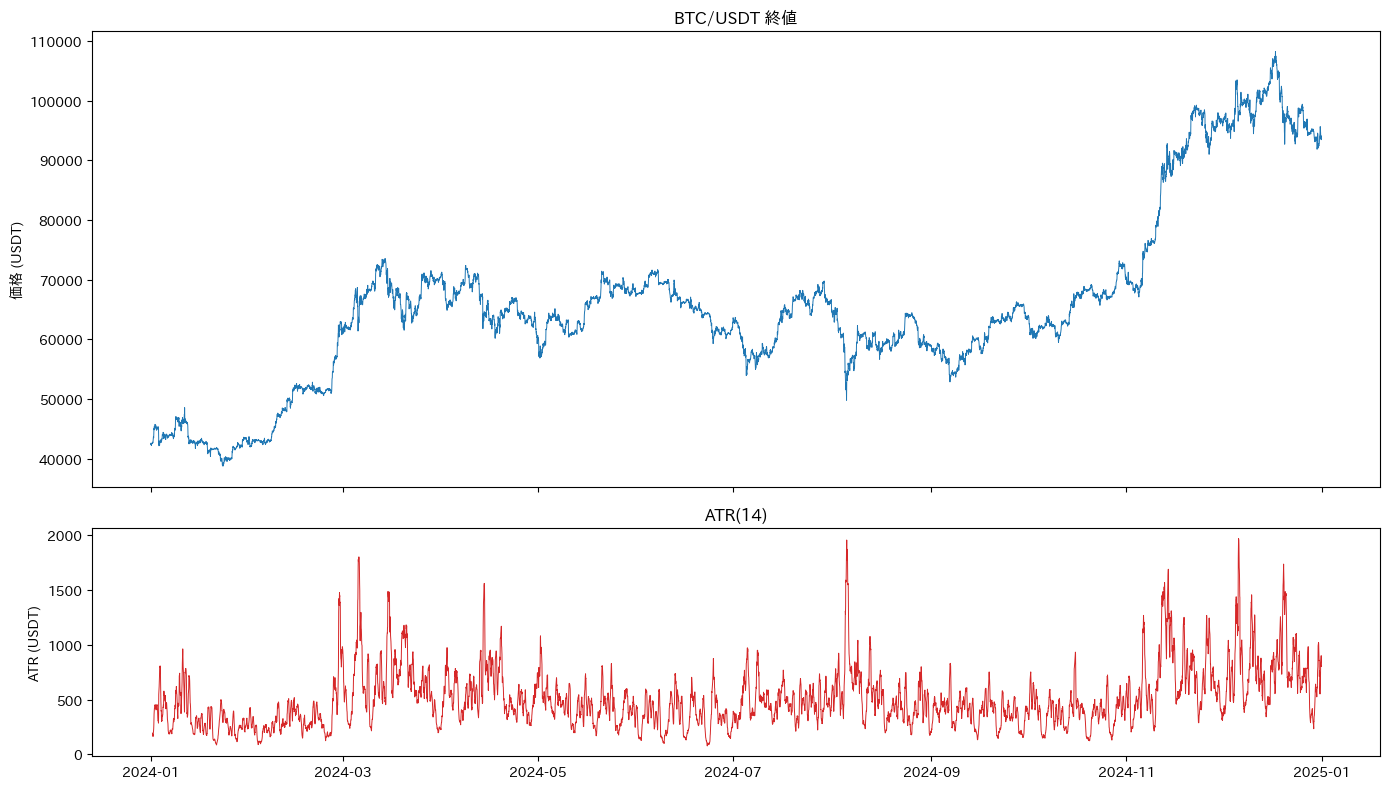

→ ATRは価格水準に依存するため、高値圏ではATRも大きくなる傾向がある
   ATRの平均: 506.1 USDT


In [10]:
# ATRのプロット
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
ax.plot(df_1h.index, df_1h["close"], linewidth=0.7, color="C0")
ax.set_title("BTC/USDT 終値")
ax.set_ylabel("価格 (USDT)")

ax = axes[1]
ax.plot(df_1h.index, df_1h["atr_14"], linewidth=0.7, color="C3")
ax.set_title("ATR(14)")
ax.set_ylabel("ATR (USDT)")

plt.tight_layout()
plt.show()

print("→ ATRは価格水準に依存するため、高値圏ではATRも大きくなる傾向がある")
print(f"   ATRの平均: {df_1h['atr_14'].mean():.1f} USDT")

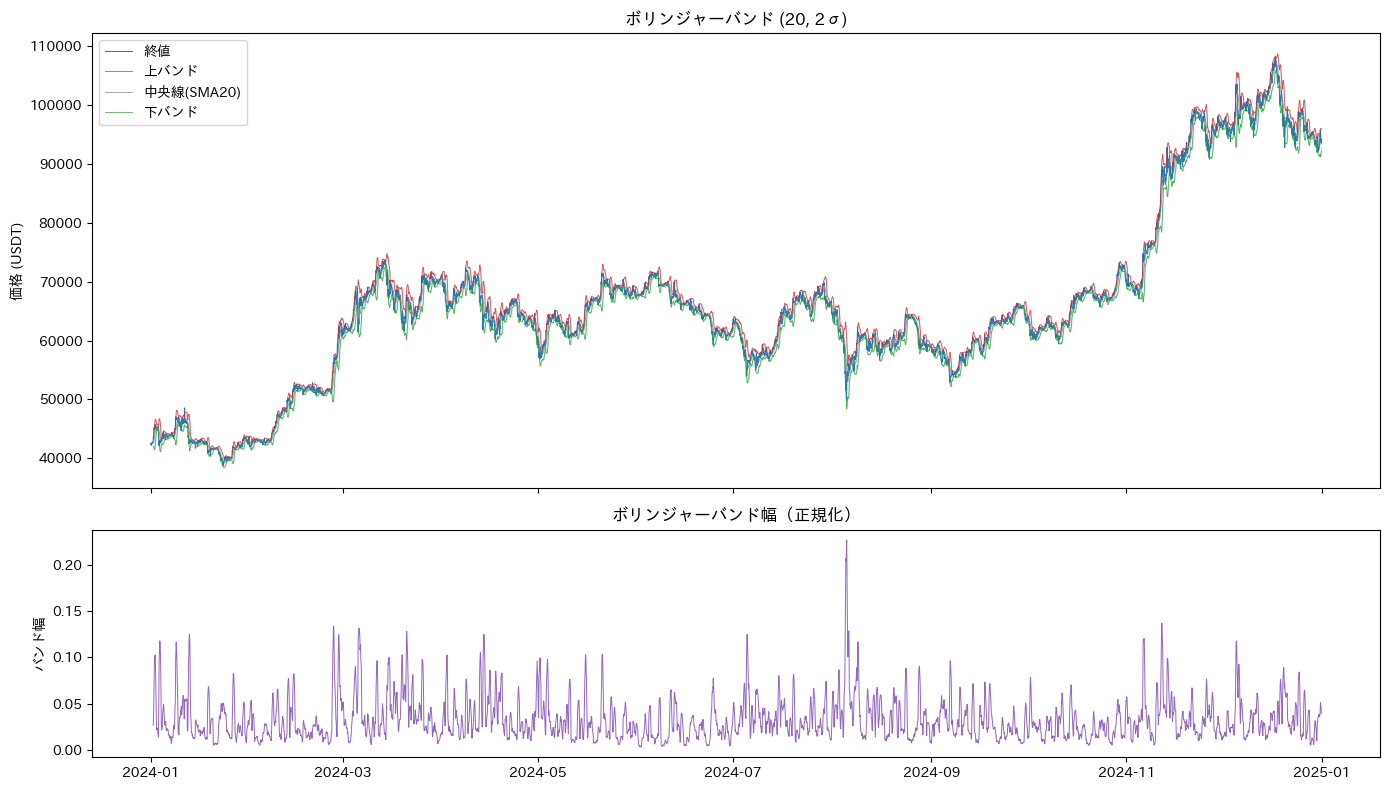

→ バンド幅が極端に縮小した後に拡大する現象を「スクイーズ → ブレイクアウト」と呼ぶ


In [11]:
# ボリンジャーバンドのプロット
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

# ボリンジャーバンドと価格
ax = axes[0]
ax.plot(df_1h.index, df_1h["close"], linewidth=0.7, color="C0", label="終値")
ax.plot(df_1h.index, df_1h["bb_upper"], linewidth=0.6, color="C3", alpha=0.8, label="上バンド")
ax.plot(df_1h.index, df_1h["bb_mid"], linewidth=0.6, color="gray", alpha=0.8, label="中央線(SMA20)")
ax.plot(df_1h.index, df_1h["bb_lower"], linewidth=0.6, color="C2", alpha=0.8, label="下バンド")
ax.fill_between(df_1h.index, df_1h["bb_upper"], df_1h["bb_lower"], alpha=0.08, color="C0")
ax.set_title("ボリンジャーバンド (20, 2σ)")
ax.set_ylabel("価格 (USDT)")
ax.legend(loc="upper left")

# バンド幅
ax = axes[1]
ax.plot(df_1h.index, df_1h["bb_width"], linewidth=0.7, color="C4")
ax.set_title("ボリンジャーバンド幅（正規化）")
ax.set_ylabel("バンド幅")

plt.tight_layout()
plt.show()

print("→ バンド幅が極端に縮小した後に拡大する現象を「スクイーズ → ブレイクアウト」と呼ぶ")

### ボラティリティ指標の読み方

| 状態 | ATR | BB幅 | 意味 |
|------|-----|-------|------|
| 高ボラティリティ | 大 | 広 | 大きな値動き、トレンド発生中の可能性 |
| 低ボラティリティ | 小 | 狭 | レンジ相場、ブレイクアウト前の静けさの可能性 |

**ATRの活用例:**
- ストップロスの設定: ATR × 2 を損切り幅にする（ボラティリティに応じた動的な設定）
- ポジションサイジング: ATRが大きいときはポジションを小さくする

**BB幅の活用例:**
- スクイーズ（バンド幅縮小）を検出し、ブレイクアウトに備える
- 価格がバンドの外に出た場合、平均回帰を期待する逆張り

## 6. 指標値と将来リターンの関係

テクニカル指標が「実際に将来の価格変動を予測できるか」を検証します。

### 方法
- **時刻 $t$ の指標値**と**時刻 $t+1$ のリターン**の関係を分析する
- 指標値は「現在わかっている情報」、リターンは「次の足の結果」
- これにより**データリーク**（未来の情報の混入）を防ぐ

### チェック項目
1. **散布図**: 指標値とリターンの関係を視覚的に確認
2. **相関係数**: 線形的な関係の強さを定量化

In [12]:
# 将来リターン（次の1時間のリターン）を計算
# ★ リーク防止: 時刻tの指標値に対して、時刻t+1のリターンを対応させる
df_1h["future_return"] = df_1h["ret"].shift(-1)

# 分析に使用する指標一覧
indicators = {
    "SMA(20) 乖離率": (df_1h["close"] - df_1h["sma_20"]) / df_1h["sma_20"] * 100,
    "EMA(20) 乖離率": (df_1h["close"] - df_1h["ema_20"]) / df_1h["ema_20"] * 100,
    "RSI(14)": df_1h["rsi_14"],
    "ROC(12)": df_1h["roc_12"],
    "ATR(14)": df_1h["atr_14"],
    "BB幅(20)": df_1h["bb_width"],
}

# 各指標と将来リターンの相関を計算
rows = []
corr_results = {}
for name, indicator in indicators.items():
    valid = pd.DataFrame({"indicator": indicator, "future_return": df_1h["future_return"]}).dropna()
    r, p = stats.pearsonr(valid["indicator"], valid["future_return"])
    corr_results[name] = {"r": r, "p": p, "n": len(valid)}
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    rows.append({
        "指標": name,
        "相関係数": round(r, 4),
        "p値": round(p, 4),
        "有意性": sig,
        "N": len(valid),
    })

corr_df = pd.DataFrame(rows).set_index("指標")

print("=== 各指標と将来リターンの相関 ===\n")
display(corr_df)

print("\n有意水準: *** p<0.001, ** p<0.01, * p<0.05, n.s. 有意でない")
print("\n⚠️ 注意点:")
print("  (1) サンプル数が多い（~8000）ため、微小な相関でも統計的に有意になりやすい")
print("  (2) テクニカル指標はrolling計算で強い自己相関を持つため、")
print("      独立標本を前提としたp値は楽観的（有意と出やすい）になる")
print("  → p値は参考値。相関の絶対値と実運用での利益が重要")

=== 各指標と将来リターンの相関 ===



,相関係数,p値,有意性,N
指標,,,,
SMA(20) 乖離率,-0.0121,0.2569,n.s.,8764
EMA(20) 乖離率,-0.0149,0.1629,n.s.,8783
RSI(14),-0.0012,0.9115,n.s.,8769
ROC(12),-0.0101,0.3450,n.s.,8771
ATR(14),0.0154,0.1480,n.s.,8770
BB幅(20),0.0269,0.0117,*,8764



有意水準: *** p<0.001, ** p<0.01, * p<0.05, n.s. 有意でない

⚠️ 注意点:
  (1) サンプル数が多い（~8000）ため、微小な相関でも統計的に有意になりやすい
  (2) テクニカル指標はrolling計算で強い自己相関を持つため、
      独立標本を前提としたp値は楽観的（有意と出やすい）になる
  → p値は参考値。相関の絶対値と実運用での利益が重要


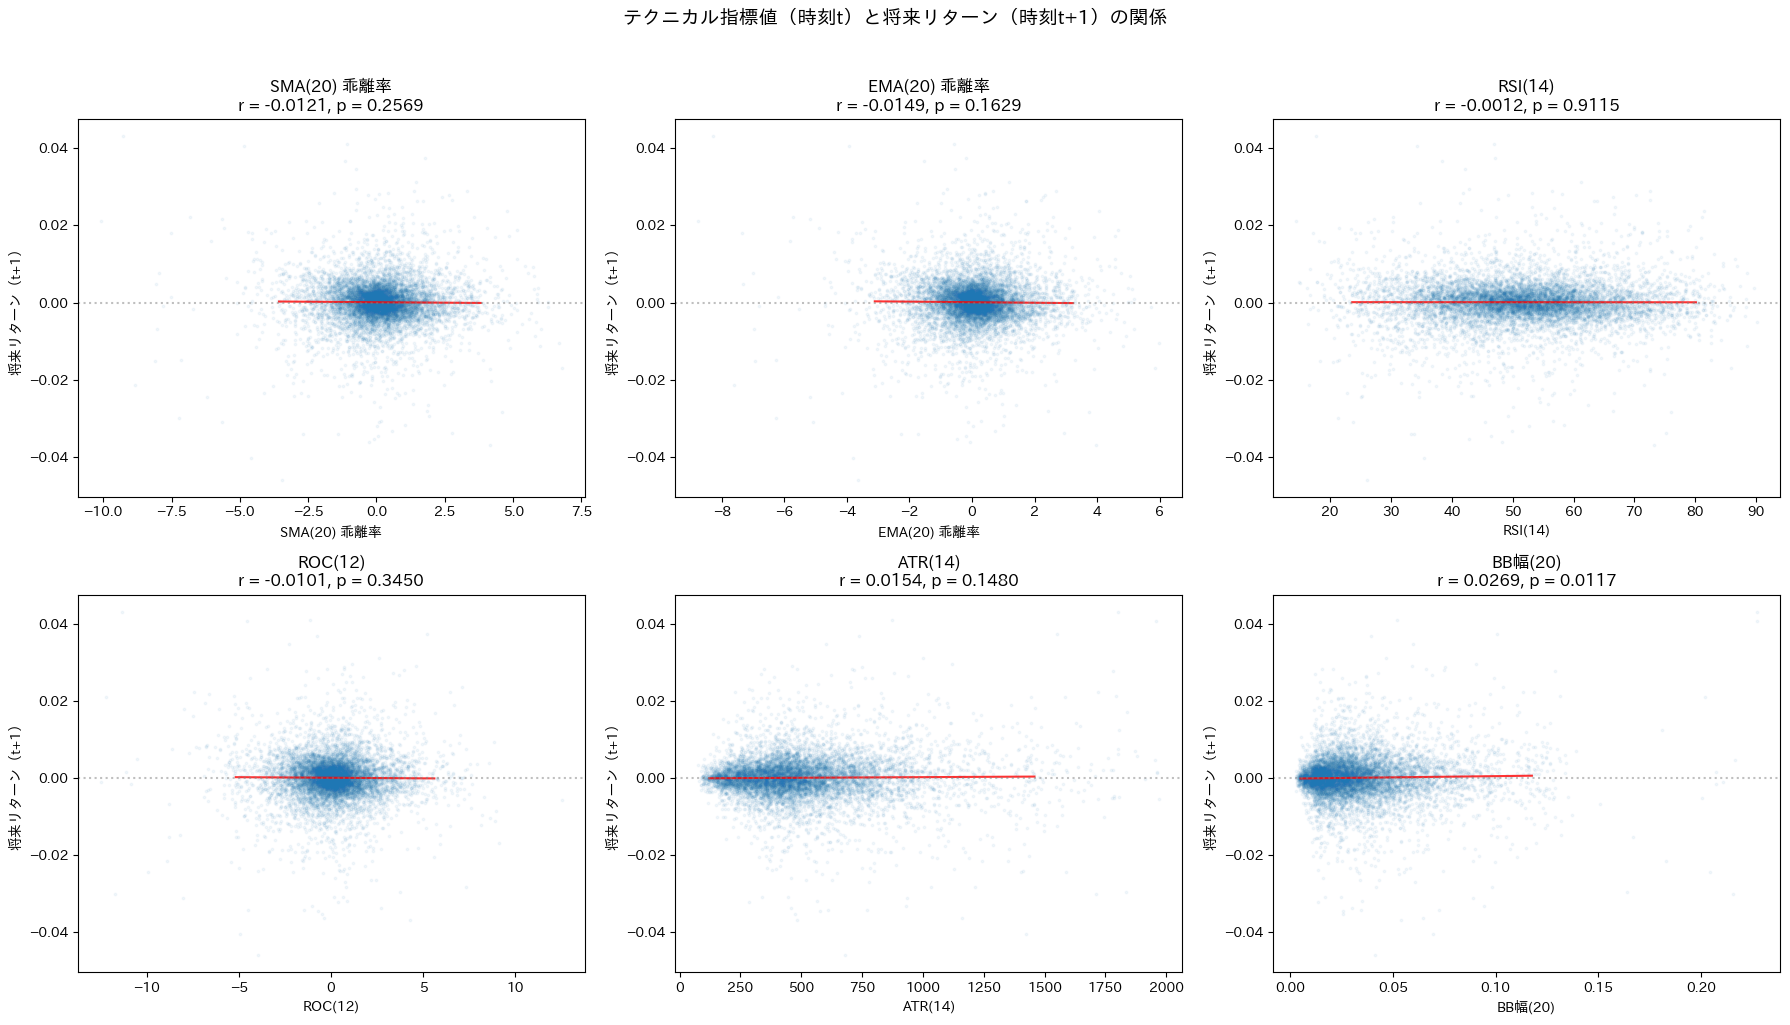

→ 散布図ではノイズが支配的だが、回帰直線の傾きに注目
  移動平均乖離率やRSIに微弱な負の相関（平均回帰傾向）が見られるかもしれない


In [13]:
# 散布図: 各指標と将来リターンの関係
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (name, indicator) in zip(axes.flat, indicators.items()):
    valid = pd.DataFrame({"x": indicator, "y": df_1h["future_return"]}).dropna()

    # データ点が多いのでアルファを下げて表示
    ax.scatter(valid["x"], valid["y"], alpha=0.05, s=3, color="C0")
    ax.set_xlabel(name)
    ax.set_ylabel("将来リターン（t+1）")

    # 相関係数を表示（p値は小数4桁に丸める）
    r = corr_results[name]["r"]
    p = corr_results[name]["p"]
    ax.set_title(f"{name}\nr = {r:.4f}, p = {p:.4f}")

    # 回帰直線
    z = np.polyfit(valid["x"], valid["y"], 1)
    x_line = np.linspace(valid["x"].quantile(0.01), valid["x"].quantile(0.99), 100)
    ax.plot(x_line, np.polyval(z, x_line), color="red", linewidth=1.5, alpha=0.8)
    ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5)

plt.suptitle("テクニカル指標値（時刻t）と将来リターン（時刻t+1）の関係", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("→ 散布図ではノイズが支配的だが、回帰直線の傾きに注目")
print("  移動平均乖離率やRSIに微弱な負の相関（平均回帰傾向）が見られるかもしれない")

### 考察: テクニカル指標に将来リターンの予測力はあるか

上の結果を見ると、**6つの指標のうち5つは将来リターンとの相関が統計的に有意ではありません**。
相関係数の絶対値もすべて0.03未満であり、散布図を見てもノイズに埋もれて関係は見えません。

#### BB幅（ボリンジャーバンド幅）の「有意な正の相関」について

唯一 p < 0.05 となったBB幅ですが、これは慎重に解釈すべきです。

BB幅が正に相関している（BB幅が大きい → 翌時間リターンがプラス寄り）ということは、「ボラティリティが高い時期ほどリターンがプラスになりやすい」ことを意味します。しかし、今回の検証期間（2024年）はBTCが全体として上昇トレンドにありました。上昇局面ではボラティリティの拡大と価格上昇が同時に起きやすいため、**BB幅とリターンの正の相関は、検証期間の相場環境に依存した見せかけの関係**である可能性が高いです。

下落トレンドの期間で同じ分析をすれば、BB幅とリターンの相関は負に転じるかもしれません。

#### テクニカル指標の組み合わせでは？

「単体で予測力がないなら、複数の指標を組み合わせればどうか」と考えるのは自然です。
実際、RSIとボリンジャーバンドを組み合わせた戦略など、テクニカル分析では一般的です。

しかし、**組み合わせの数が増えるほど、以下のリスクが急速に高まります**。

- **オーバーフィッティング**: 過去のデータに偶然フィットするルールを「発見」してしまう
- **多重比較の問題**: 多数の組み合わせを試すと、偶然だけでも良い結果が出るものが見つかる（Vol.04で触れたBonferroni補正と同じ問題）

たとえば100通りの戦略をα=0.05で検定すると、すべて無効な戦略であっても少なくとも1つが「有意」になる確率は約99.4%です。組み合わせ戦略を評価する際は、Vol.08（頑健性検証）やVol.10（ブートストラップ検定）で過学習を排除する手続きが不可欠です。

### リークチェック

上の分析ではリークが発生していないことを確認します。

- **指標値（横軸）**: 時刻 $t$ までのデータのみで計算（過去のOHLCVの関数）
- **将来リターン（縦軸）**: 時刻 $t+1$ のリターン = `close[t+1] / close[t] - 1`
- `shift(-1)` で将来リターンを1足ずらしているため、**時刻 $t$ の指標で時刻 $t+1$ の結果を予測**する構造になっている

→ リークなし

### 相関係数の p 値の解釈に関する注意

上の相関分析では、ピアソン相関係数の p 値を計算しています。
このp 値は **「データが正規分布に従い、かつ独立である」** という仮定のもとで計算されています。

しかし Vol.02 で確認したとおり、暗号資産のリターン分布は**ファットテール**（正規分布より裾が厚い）です。
また、ボラティリティには**クラスタリング**（大きな変動の後に大きな変動が続きやすい）があり、データは独立ではありません。

そのため、ここで得られた p 値は **参考値** として捉えてください。
「相関があるかないか」の大まかな判断には使えますが、p = 0.03 と p = 0.07 の差に大きな意味を見出すべきではありません。
指標の有効性をより厳密に評価するには、Vol.9（五分位分析）やVol.10（ブートストラップ検定）の手法が必要です。

## 7. 指標の自己相関

テクニカル指標の値が「粘着的」かどうかを調べます。

### なぜ自己相関が重要か

- **自己相関が高い**指標: 値がゆっくり変化する → トレンドフォロー向き
- **自己相関が低い**指標: 値が素早く変化する → 短期のシグナル向き
- 自己相関構造を知ることで、指標の特性に合ったトレード戦略を設計できる

### 方法
- 各指標のラグ $k$ における自己相関 $\text{Corr}(X_t, X_{t+k})$ を計算
- ラグ1〜48（1時間足で最大2日分）を対象にする

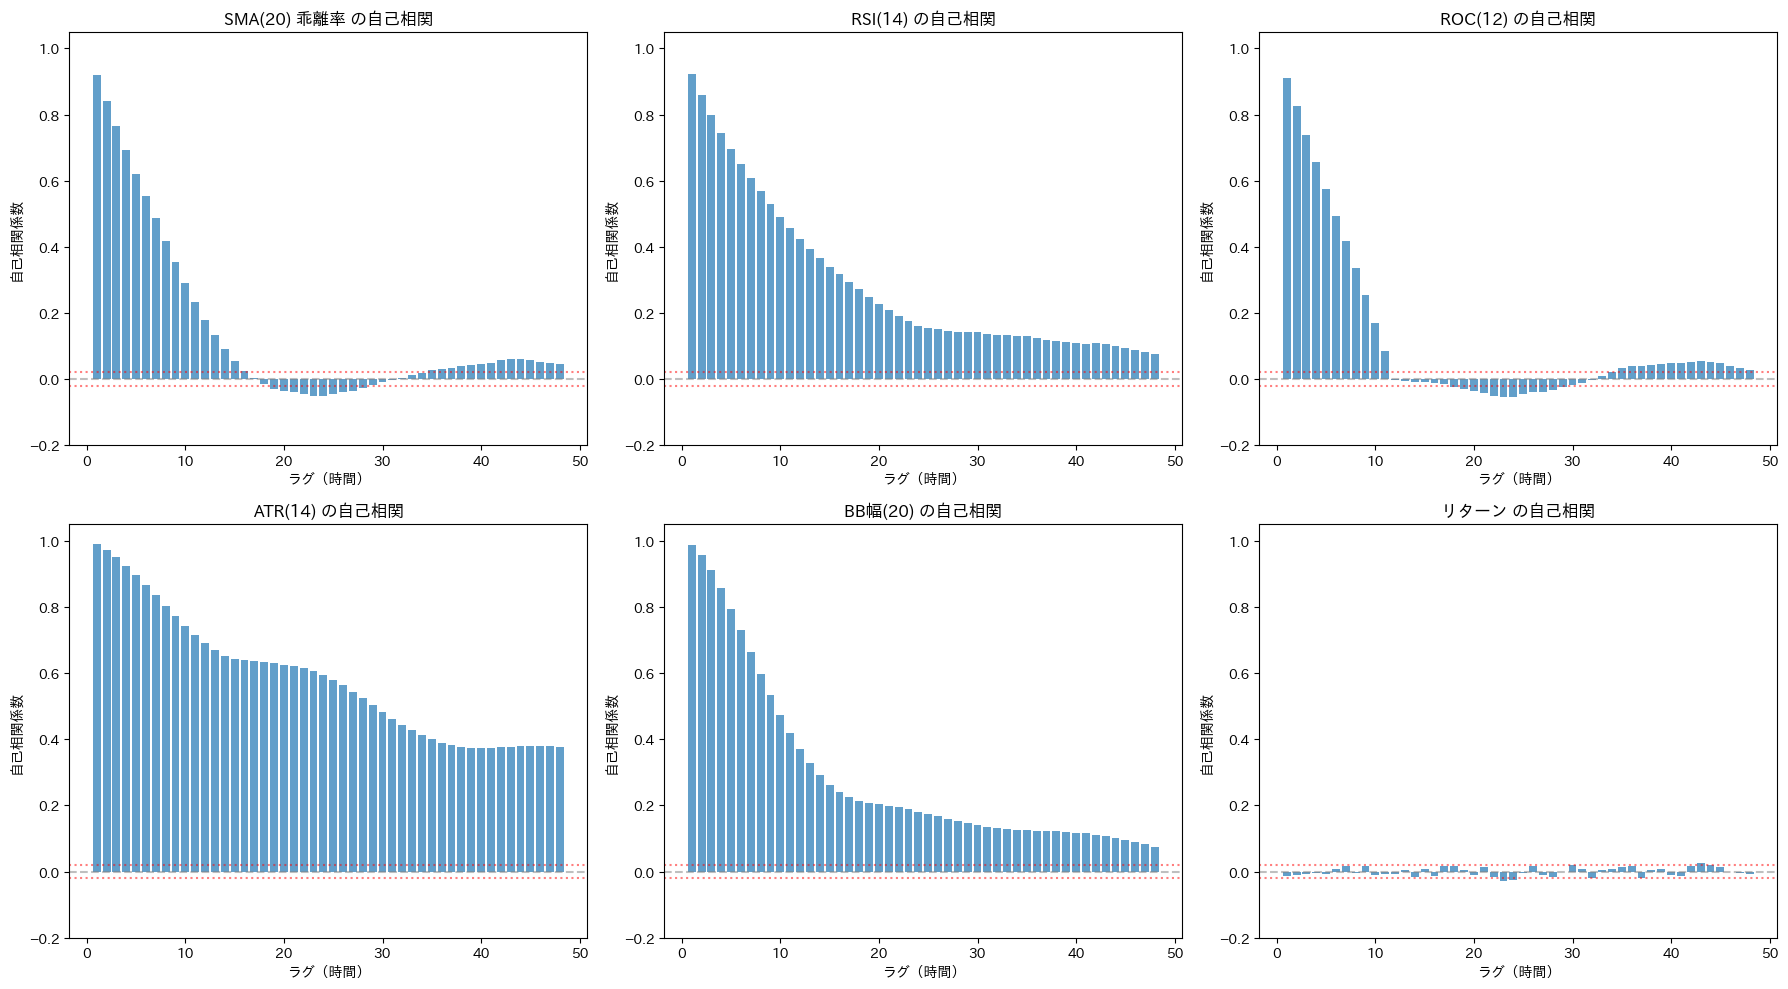

In [14]:
# 各指標の自己相関を計算
max_lag = 48  # 最大48時間（2日分）

# 分析対象の指標
autocorr_indicators = {
    "SMA(20) 乖離率": (df_1h["close"] - df_1h["sma_20"]) / df_1h["sma_20"] * 100,
    "RSI(14)": df_1h["rsi_14"],
    "ROC(12)": df_1h["roc_12"],
    "ATR(14)": df_1h["atr_14"],
    "BB幅(20)": df_1h["bb_width"],
    "リターン": df_1h["ret"],
}

autocorr_df = pd.DataFrame(index=range(1, max_lag + 1))
for name, indicator in autocorr_indicators.items():
    autocorr_values = []
    for lag in range(1, max_lag + 1):
        ac = indicator.autocorr(lag=lag)
        autocorr_values.append(ac)
    autocorr_df[name] = autocorr_values

# プロット
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, autocorr_df.columns):
    ax.bar(autocorr_df.index, autocorr_df[col], color="C0", alpha=0.7, width=0.8)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    # 95%信頼区間を表示（白色ノイズの場合の境界）
    n = len(df_1h[col].dropna()) if col in df_1h.columns else len(df_1h)
    ci_95 = 1.96 / np.sqrt(len(df_1h))
    ax.axhline(y=ci_95, color="red", linestyle=":", alpha=0.5, label="95%信頼限界")
    ax.axhline(y=-ci_95, color="red", linestyle=":", alpha=0.5)
    ax.set_title(f"{col} の自己相関")
    ax.set_xlabel("ラグ（時間）")
    ax.set_ylabel("自己相関係数")
    ax.set_ylim(-0.2, 1.05)

plt.tight_layout()
plt.show()

In [15]:
# 自己相関の特徴を数値で比較
selected_lags = [1, 6, 12, 24, 48]

ac_summary = pd.DataFrame(
    {col: [autocorr_df[col].iloc[l - 1] for l in selected_lags] for col in autocorr_df.columns},
    index=[f"lag={l}" for l in selected_lags]
).T
ac_summary.index.name = "指標"

print("=== 各指標の自己相関の特徴 ===\n")
display(ac_summary.round(3))

print("\n解釈:")
print("- SMA乖離率・RSI・ATR・BB幅: 自己相関が非常に高い（粘着的）")
print("  → これらの指標は「レジーム」（上昇トレンド、高ボラ等）を反映しており、状態が持続する")
print("- リターン: 自己相関がほぼゼロ")
print("  → 価格のリターン自体は予測困難（効率的市場仮説と整合的）")
print("- ROC: SMAやRSIより自己相関の減衰が早い")
print("  → より短期的な情報を持つ指標")

=== 各指標の自己相関の特徴 ===



,lag=1,lag=6,lag=12,lag=24,lag=48
指標,,,,,
SMA(20) 乖離率,0.919,0.553,0.180,-0.051,0.047
RSI(14),0.922,0.650,0.423,0.161,0.076
ROC(12),0.911,0.494,-0.004,-0.053,0.028
ATR(14),0.991,0.867,0.692,0.595,0.375
BB幅(20),0.987,0.730,0.370,0.182,0.074
リターン,-0.014,0.007,-0.008,-0.026,-0.009



解釈:
- SMA乖離率・RSI・ATR・BB幅: 自己相関が非常に高い（粘着的）
  → これらの指標は「レジーム」（上昇トレンド、高ボラ等）を反映しており、状態が持続する
- リターン: 自己相関がほぼゼロ
  → 価格のリターン自体は予測困難（効率的市場仮説と整合的）
- ROC: SMAやRSIより自己相関の減衰が早い
  → より短期的な情報を持つ指標


## 8. 複数指標間の相関（冗長性チェック）

複数のテクニカル指標を組み合わせて戦略を構築する場面は多いですが、その際に**指標間の冗長性**を確認しておくことが非常に重要です。

### なぜ冗長性が問題か

- **情報の重複**: 相関の高い指標を2つ使っても、1つ使うのとほぼ同じ情報しか得られない。指標を「2つ使っている」という安心感だけで、実質的な予測力は向上しない
- **過学習のリスク**: 似た情報を持つ指標を複数組み合わせると、パラメータの数だけが増え、バックテストでは良い結果が出るが実運用で再現できないリスクが高まる
- **解釈の困難**: 相関の高い指標が同時にシグナルを出した場合、「2つの独立した根拠がある」と誤解しやすい。実際にはほぼ同じことを2回言っているだけ

### 理想的な指標の組み合わせ

**異なる側面**を捉える指標を組み合わせることが重要です。

| カテゴリ | 指標 | 捉える側面 |
|----------|------|------------|
| トレンド系 | SMA乖離率, EMA乖離率 | トレンドの方向と強さ |
| モメンタム・オシレーター系 | RSI, ROC | 価格変動の勢いの強弱 |
| ボラティリティ系 | ATR, BB幅 | 値動きの大きさ |

仮説: **同じカテゴリ内**の指標は高い相関を持ち（冗長）、**異なるカテゴリ間**では相関が低い（補完的）はず。以下でこれを検証します。

In [16]:
# 各指標の値をDataFrameにまとめる
indicators_for_corr = pd.DataFrame({
    "SMA(20)乖離率": (df_1h["close"] - df_1h["sma_20"]) / df_1h["sma_20"] * 100,
    "EMA(20)乖離率": (df_1h["close"] - df_1h["ema_20"]) / df_1h["ema_20"] * 100,
    "RSI(14)": df_1h["rsi_14"],
    "ROC(12)": df_1h["roc_12"],
    "ATR(14)": df_1h["atr_14"],
    "BB幅(20)": df_1h["bb_width"],
}).dropna()

# 相関行列を計算
corr_matrix = indicators_for_corr.corr()

print("=== テクニカル指標間の相関行列 ===\n")
display(corr_matrix.round(3))

=== テクニカル指標間の相関行列 ===



,SMA(20)乖離率,EMA(20)乖離率,RSI(14),ROC(12),ATR(14),BB幅(20)
SMA(20)乖離率,1.000,0.982,0.888,0.940,-0.059,0.048
EMA(20)乖離率,0.982,1.000,0.918,0.902,-0.067,0.031
RSI(14),0.888,0.918,1.000,0.815,-0.066,0.045
ROC(12),0.940,0.902,0.815,1.000,-0.046,0.056
ATR(14),-0.059,-0.067,-0.066,-0.046,1.000,0.689
BB幅(20),0.048,0.031,0.045,0.056,0.689,1.000


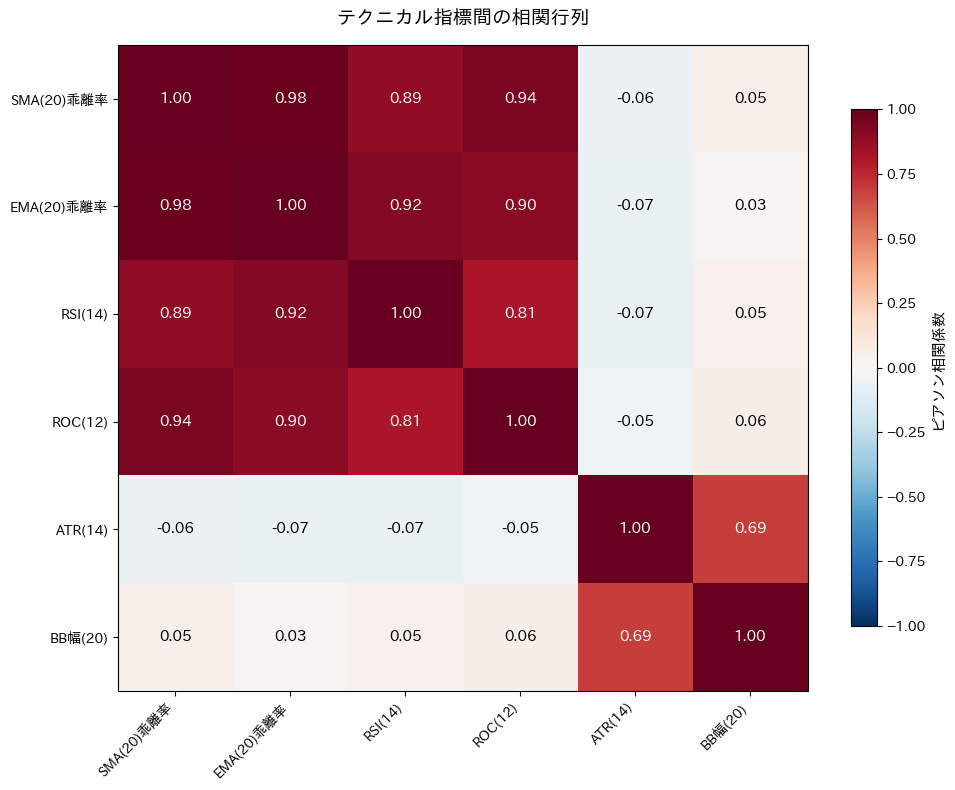

In [17]:
# 相関行列のヒートマップ（matplotlibのみで実装）
fig, ax = plt.subplots(figsize=(10, 8))

# 相関行列をヒートマップとして表示
labels = corr_matrix.columns.tolist()
n = len(labels)
data = corr_matrix.values

# カラーマップの設定
im = ax.imshow(data, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

# 軸ラベルの設定
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

# セルに値を表示
for i in range(n):
    for j in range(n):
        color = "white" if abs(data[i, j]) > 0.6 else "black"
        ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center",
                fontsize=11, fontweight="bold", color=color)

# カラーバー
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("ピアソン相関係数", fontsize=11)

ax.set_title("テクニカル指標間の相関行列", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [18]:
# 冗長性の評価
print("=== 冗長性の評価 ===")
print()

# カテゴリ内の相関
print("【同一カテゴリ内の相関】")
print(f"  トレンド系:     SMA乖離率 ↔ EMA乖離率  = {corr_matrix.loc['SMA(20)乖離率', 'EMA(20)乖離率']:.3f}")
print(f"  モメンタム・オシレーター系:   RSI(14) ↔ ROC(12)       = {corr_matrix.loc['RSI(14)', 'ROC(12)']:.3f}")
print(f"  ボラティリティ: ATR(14) ↔ BB幅(20)       = {corr_matrix.loc['ATR(14)', 'BB幅(20)']:.3f}")
print()

# カテゴリ間の相関
print("【異なるカテゴリ間の相関（代表例）】")
cross_pairs = [
    ("SMA(20)乖離率", "RSI(14)", "トレンド ↔ モメンタム・オシレーター"),
    ("SMA(20)乖離率", "ATR(14)", "トレンド ↔ ボラティリティ"),
    ("RSI(14)", "BB幅(20)", "モメンタム・オシレーター ↔ ボラティリティ"),
]
for col1, col2, label in cross_pairs:
    r = corr_matrix.loc[col1, col2]
    print(f"  {label}: {col1} ↔ {col2} = {r:.3f}")

print()
print("【結論】")
print("- 同一カテゴリ内: 高い相関 → 片方だけ使えば十分（冗長）")
print("- トレンド ↔ モメンタム・オシレーター: 中〜高程度の相関")
print("  → RSIはトレンド方向の情報も含むため、完全に独立ではない")
print("- トレンド/モメンタム・オシレーター ↔ ボラティリティ: 低い相関")
print("  → ボラティリティ指標は異なる情報を提供しており、組み合わせる価値がある")

=== 冗長性の評価 ===

【同一カテゴリ内の相関】
  トレンド系:     SMA乖離率 ↔ EMA乖離率  = 0.982
  モメンタム・オシレーター系:   RSI(14) ↔ ROC(12)       = 0.815
  ボラティリティ: ATR(14) ↔ BB幅(20)       = 0.689

【異なるカテゴリ間の相関（代表例）】
  トレンド ↔ モメンタム・オシレーター: SMA(20)乖離率 ↔ RSI(14) = 0.888
  トレンド ↔ ボラティリティ: SMA(20)乖離率 ↔ ATR(14) = -0.059
  モメンタム・オシレーター ↔ ボラティリティ: RSI(14) ↔ BB幅(20) = 0.045

【結論】
- 同一カテゴリ内: 高い相関 → 片方だけ使えば十分（冗長）
- トレンド ↔ モメンタム・オシレーター: 中〜高程度の相関
  → RSIはトレンド方向の情報も含むため、完全に独立ではない
- トレンド/モメンタム・オシレーター ↔ ボラティリティ: 低い相関
  → ボラティリティ指標は異なる情報を提供しており、組み合わせる価値がある


## 9. まとめ

このnotebookでは、テクニカル指標を**自分で実装**し、その**統計的な性質**を定量的に評価しました。

### 学んだこと

| テーマ | 内容 | ポイント |
|--------|------|----------|
| 移動平均（SMA, EMA） | トレンド方向の把握 | EMAはSMAより反応が早い。ウィンドウ幅はトレードオフ |
| RSI, ROC | モメンタム・オシレーター（勢い）の定量化 | RSIは0〜100に正規化され扱いやすい。ROCはシンプルな変化率 |
| ATR, BB幅 | ボラティリティの測定 | リスク管理に不可欠。ATRは絶対値、BB幅は正規化された指標 |
| 指標 vs 将来リターン | 予測力の検証 | 6指標中5つは非有意。唯一有意なBB幅も環境依存の可能性が高い |
| 自己相関 | 指標の粘着性 | SMA乖離率、RSI、ATRは非常に粘着的（ゆっくり変化する） |
| 指標間の相関 | 冗長性チェック | 同カテゴリは冗長。異なるカテゴリの組み合わせが有効 |

### 重要なポイント

1. **テクニカル指標は「遅行指標」である**
   - いずれの指標も過去のデータから計算するため、本質的にラグがある
   - 「トレンドが発生してからシグナルが出る」ことを常に意識する

2. **単一指標の予測力はほぼ確認できなかった**
   - 6つの指標すべてで、将来リターンとの相関は0.03未満だった
   - 唯一p<0.05だったBB幅も、検証期間の上昇トレンドに依存した見せかけの関係である可能性が高い
   - **「有意な結果が出た」ときこそ、環境依存性や多重比較を疑う習慣**が重要

3. **指標の組み合わせにも罠がある**
   - 複数の指標を組み合わせれば予測力が上がる可能性はあるが、試す組み合わせの数が増えるほどオーバーフィッティングと多重比較のリスクが高まる
   - 組み合わせ戦略の評価にはVol.08（ウォークフォワード検証）やVol.10（ブートストラップ検定）が不可欠

4. **p値を鵜呑みにしない**
   - ファットテール分布やボラティリティ・クラスタリングにより、正規分布・独立性を前提としたp値は楽観的になる
   - サンプル数が大きい（~8,000本）ため、実質的に無意味な相関でも統計的に有意と出やすい
   - p値は大まかなスクリーニングに使い、最終的な評価はVol.9（五分位分析）やVol.10（ブートストラップ）で行う

5. **冗長な指標を重ねても意味がない**
   - SMA乖離率とEMA乖離率は高い相関を持ち、両方使う利点は少ない
   - 異なるカテゴリ（トレンド＋ボラティリティなど）から指標を選ぶべき

6. **自己相関は戦略設計のヒントになる**
   - 粘着的な指標は「レジーム検出」に向いている
   - 素早く変化する指標は「短期のエントリーシグナル」に向いている

### このnotebookの位置づけ

冒頭で述べたとおり、テクニカル指標は万能ではなく、全期間を通じて安定した収益を出す単一の指標はほぼ存在しません。このnotebookの目的は「テクニカル指標で儲ける」ことではなく、**指標を作成し、評価するワークフローを身につける**ことでした。

そして、テクニカル指標だけでは将来リターンの予測が難しいという結果は、**価格データの外側に目を向ける動機**になります。ここで学んだ「指標を作る → 散布図・相関で評価 → 自己相関 → 冗長性チェック」の流れは、Vol.06以降で扱うCoinbaseプレミアムのような外部指標にもそのまま適用できます。

### 次のステップ

**Vol.06** では、Coinbaseプレミアム（取引所間の価格差）という外部指標を題材に、指標の探索プロセスを実践します。テクニカル指標とは異なる情報源から予測力を探るアプローチです。

## 分析結果から分かったこと

### 指標と将来リターンの関係
- 全指標で相関係数の絶対値が0.03以下と非常に小さく、1時間足の次バーリターンに対する個別の予測力は極めて限定的
- BB幅（ボラティリティ指標）のみp<0.05で有意だったが、検証期間（2024年）の上昇トレンドに依存した見せかけの関係である可能性が高い
- テクニカル指標単体では将来リターンをほとんど予測できないという結果は、価格データ以外の情報源を探す動機になる

### 指標の自己相関（粘着性）
- ATR(14)は2日後でも高い自己相関を持ち極めて粘着的。ボラティリティは持続する性質がある
- RSI(14)も比較的粘着。一方リターンの自己相関はほぼゼロ
- 指標値は「急に変わらない」性質があり、シグナルの転換は稀

### 指標間の冗長性
- SMA乖離率とEMA乖離率は極めて冗長 → 片方で十分
- トレンド系とモメンタム・オシレーター系も高相関 → 情報の重複が大きい
- 一方、トレンド系 vs ボラティリティ系の相関はほぼゼロで独立 → 組み合わせる価値あり
- **異なるカテゴリの指標を組み合わせること**が、情報量を増やすうえで重要

---

**暗号資産データ分析入門シリーズ Vol.05 完**

テクニカル指標は「万能な予測ツール」ではなく、市場の状態を**定量的に記述するための道具**です。
その性質を正しく理解した上で使うことが、データドリブンなトレード戦略の第一歩になります。